In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
import tensorflow as tf

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_parquet("with_CID.parquet")


print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (82408, 40)


,PPI_LEN,PPI_ROUNDTRIPS,log_ppi_duration,log_mean_ipt,log_std_ipt,mean_packet_size,std_packet_size,direction_change_ratio,forward_packet_ratio,occid_length,...,log_byte_rate,avg_packet_size,log_byte_ratio,log_packet_ratio,quic_version_id,QUIC_TOKEN_LENGTH,log_zero_rtt,zero_rtt_present,log_multiplexed,multiplexed
0,21,4,0.182322,2.353640,3.109561,278.523810,441.632968,0.400000,0.523810,0,...,10.376670,306.523810,1.025248,0.741937,0,0,0.693147,1,0.0,0
1,30,3,0.043059,0.902868,1.504042,1011.666667,510.923434,0.172414,0.200000,0,...,6.996255,697.731844,0.080153,0.459998,5,0,0.000000,0,0.0,0
2,22,5,4.110644,7.911191,9.431400,460.636364,500.916845,0.428571,0.500000,0,...,5.194109,488.636364,1.098147,0.693147,2,0,0.000000,0,0.0,0
3,30,7,0.183987,2.045540,3.163525,384.866667,454.480343,0.448276,0.400000,0,...,9.678264,358.213740,0.293910,0.544464,2,60,1.098612,1,0.0,0
4,17,4,0.116004,2.108429,2.607685,333.882353,421.149252,0.500000,0.470588,0,...,10.824597,361.882353,0.585384,0.635989,0,0,0.000000,0,0.0,0


In [4]:
X_train, X_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (65926, 40)
Testing Shape  : (16482, 40)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=df.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=df.columns,
    index=X_test.index
)

In [7]:
from tensorflow.keras.layers import (
    Input, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(input_layer)
x = Dropout(0.1)(x)

x = Dense(
    32,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(x)
x = Dropout(0.1)(x)

x = Dense(
    16,
    activation='relu',
    kernel_regularizer=l2(1e-5)
)(x)

# Latent Space
latent = Dense(
    10,
    activation='linear',
    name='latent'
)(x)

# Decoder
x = Dense(16, activation='relu')(latent)
x = Dense(32, activation='relu')(x)
x = Dense(64, activation='relu')(x)

output_layer = Dense(
    input_dim,
    activation='linear'
)(x)

autoencoder = Model(input_layer, output_layer)
encoder_model = Model(input_layer, latent)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=200,
    batch_size=2048,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.9754 - val_loss: 0.9055
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.8310 - val_loss: 0.7185
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6702 - val_loss: 0.5802
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.5663 - val_loss: 0.4988
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5087 - val_loss: 0.4516
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4687 - val_loss: 0.4166
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4386 - val_loss: 0.3866
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4111 - val_loss: 0.3625
Epoch 9/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3886 - val_loss: 0.3393
Epoch 10/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3675 - val_loss: 0.3205
Epoch 11/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3505 - val_loss: 0.3047
Epoch 12/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

In [8]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 40)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent (Dense)                       │ (None, 10)                  │             170 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 40)                  │           2,600 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,504 (126.97 KB)

 Trainable params: 10,834 (42.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,670 (84.65 KB)

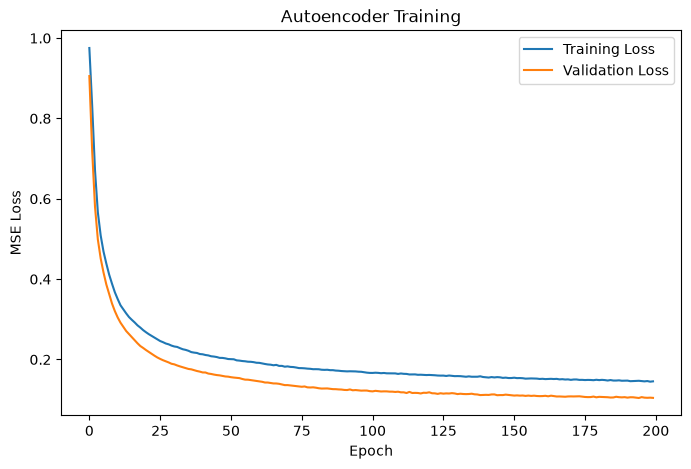

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")

plt.legend()

plt.show()

In [10]:
latent_train = encoder_model.predict(X_train_scaled)

latent_test = encoder_model.predict(X_test_scaled)

print("Train:", latent_train.shape)
print("Test :", latent_test.shape)

2061/2061 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train: (65926, 10)
Test : (16482, 10)


In [11]:
latent_columns = [f"latent_{i+1}" for i in range(10)]

latent_train = pd.DataFrame(
    latent_train,
    columns=latent_columns
)

latent_test = pd.DataFrame(
    latent_test,
    columns=latent_columns
)

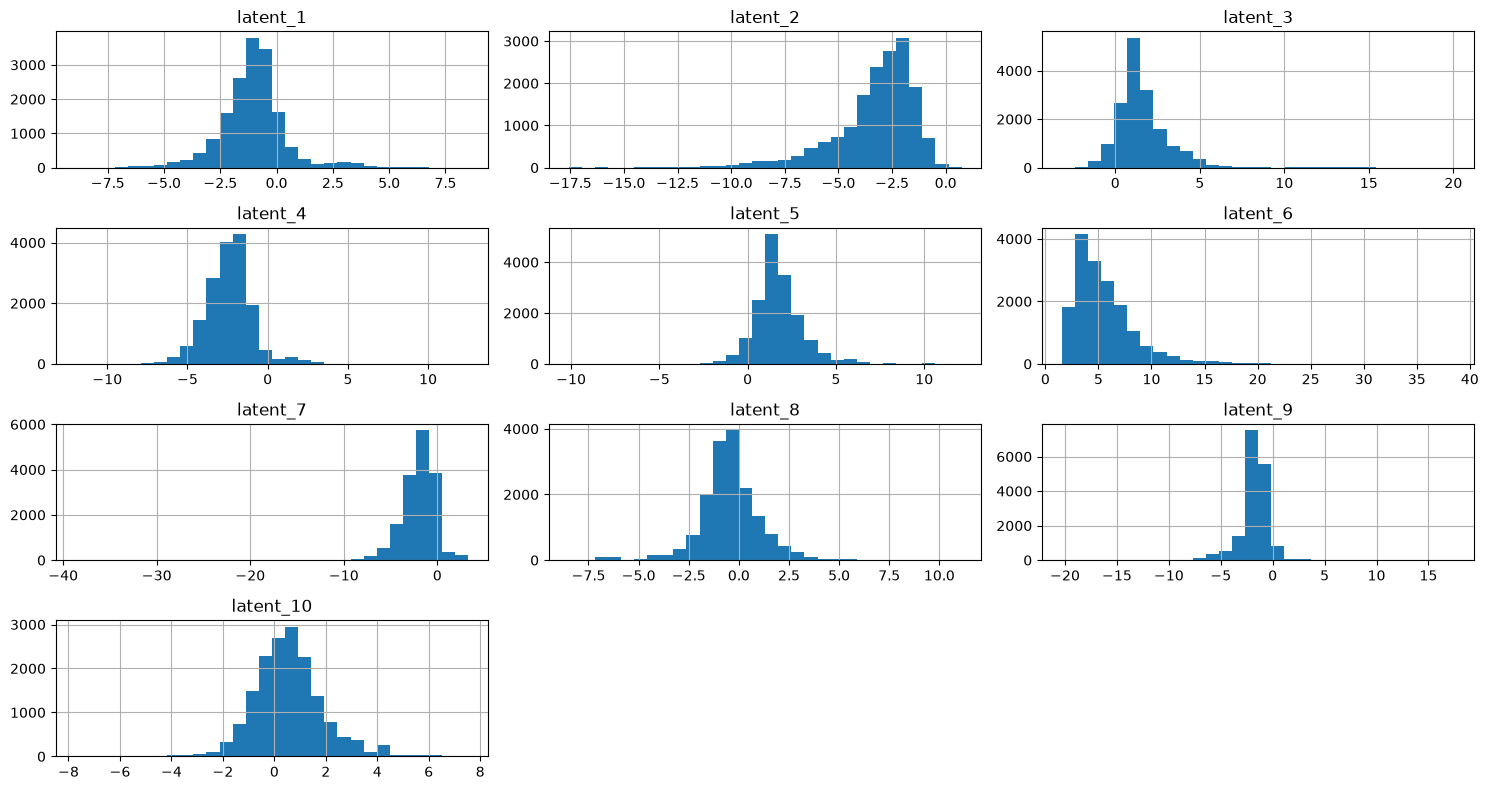

In [12]:
latent_test.hist(
    figsize=(15,8),
    bins=30
)

plt.tight_layout()
plt.show()

In [13]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

In [14]:
iso_forest.fit(latent_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [15]:
predictions = iso_forest.predict(latent_test)
anomaly_scores = -iso_forest.score_samples(latent_test)

In [16]:
results = latent_test.copy()

results["anomaly_score"] = anomaly_scores

results["prediction"] = predictions

results.head()

,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,anomaly_score,prediction
0,-1.000285,-1.905794,-0.676738,-2.679859,1.789668,3.504605,-0.375457,-1.564394,-2.362860,0.634730,0.391583,1
1,-5.710405,-7.178404,2.523206,-7.201777,5.706228,17.570946,-6.760588,-2.266325,-0.519056,1.422817,0.613028,-1
2,-1.227657,-2.766949,0.999254,-2.488499,1.789285,4.452417,-0.641181,-0.514295,-1.644536,1.698496,0.356193,1
3,-1.343405,-2.062212,1.323815,-3.379874,1.795712,3.191377,-1.321518,0.546480,-2.273471,-0.064397,0.366379,1
4,0.161589,-2.950143,0.536240,-3.445060,1.335759,5.782499,-2.341433,-1.053071,-1.661695,0.192339,0.375460,1


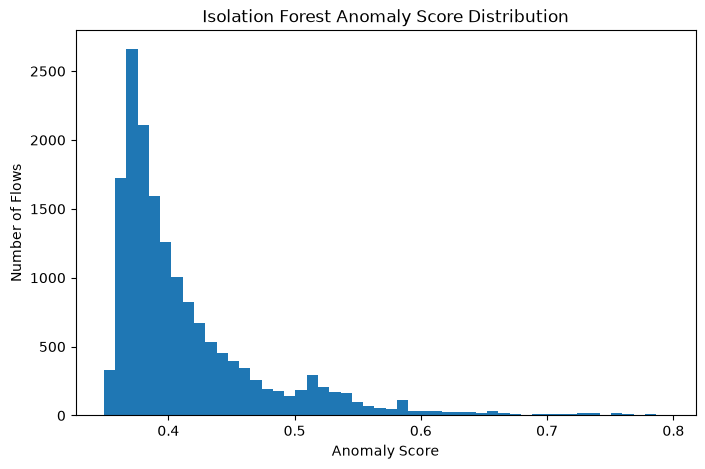

In [17]:
plt.figure(figsize=(8,5))

plt.hist(anomaly_scores,
         bins=50)

plt.xlabel("Anomaly Score")

plt.ylabel("Number of Flows")

plt.title("Isolation Forest Anomaly Score Distribution")

plt.show()

In [18]:
score_series = pd.Series(anomaly_scores)

print(score_series.describe())

print("\nSkewness:", score_series.skew())

count    16482.000000
mean         0.415241
std          0.063934
min          0.348896
25%          0.373693
50%          0.392432
75%          0.431626
max          0.795309
dtype: float64

Skewness: 2.2226061823211642


In [19]:
print("Normal flows :", np.sum(predictions == 1))
print("Anomalous flows :", np.sum(predictions == -1))

Normal flows : 14676
Anomalous flows : 1806


In [20]:
results = df.loc[X_test.index].copy()
results["anomaly_score"] = anomaly_scores

In [21]:
threshold = np.percentile(anomaly_scores, 95)

normal = results[results["anomaly_score"] < threshold]
anomalous = results[results["anomaly_score"] >= threshold]

print("Normal flows:", len(normal))
print("Anomalous flows:", len(anomalous))

Normal flows: 15657
Anomalous flows: 825


In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=2)

latent_pca = pca.fit_transform(latent_test)

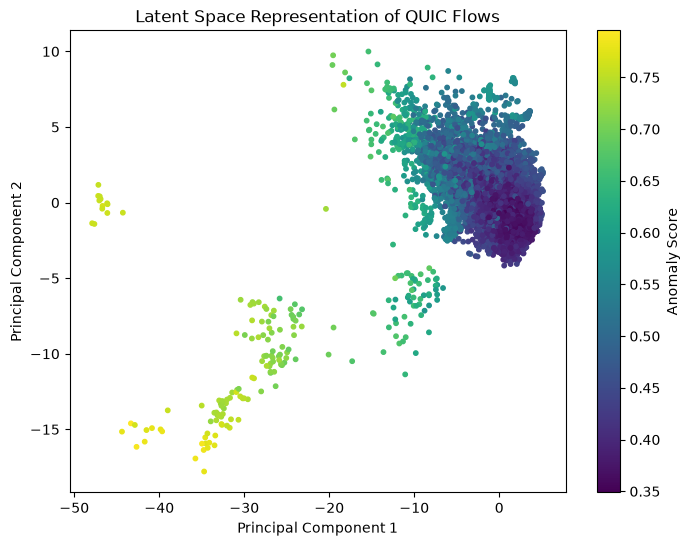

In [24]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_pca[:,0],
    latent_pca[:,1],
    c=anomaly_scores,
    cmap="viridis",
    s=10
)

plt.colorbar(scatter, label="Anomaly Score")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Latent Space Representation of QUIC Flows")

plt.show()

In [25]:
seeds = [42, 100, 200, 500]


score_df = pd.DataFrame(index=latent_test.index)

for seed in seeds:

    iso = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=seed
    )

    iso.fit(latent_train)

    score_df[f"Seed_{seed}"] = -iso.score_samples(latent_test)

score_df.head()

,Seed_42,Seed_100,Seed_200,Seed_500
0,0.391583,0.391446,0.394693,0.382022
1,0.613028,0.614117,0.641832,0.620835
2,0.356193,0.357558,0.358903,0.361758
3,0.366379,0.366618,0.364209,0.366586
4,0.375460,0.365357,0.371816,0.364241


In [26]:
correlation = score_df.corr()

correlation

,Seed_42,Seed_100,Seed_200,Seed_500
Seed_42,1.000000,0.991932,0.991021,0.989984
Seed_100,0.991932,1.000000,0.993771,0.992163
Seed_200,0.991021,0.993771,1.000000,0.992956
Seed_500,0.989984,0.992163,0.992956,1.000000


In [27]:
top_anomalies = {}

for column in score_df.columns:

    threshold = score_df[column].quantile(0.95)

    top_anomalies[column] = set(
        score_df.index[
            score_df[column] >= threshold
        ]
    )

In [28]:
from itertools import combinations

overlap_results = []

for seed_1, seed_2 in combinations(score_df.columns, 2):

    common = len(
        top_anomalies[seed_1].intersection(
            top_anomalies[seed_2]
        )
    )

    total = len(top_anomalies[seed_1])

    overlap = (common / total) * 100

    overlap_results.append([
        seed_1,
        seed_2,
        common,
        round(overlap,2)
    ])

overlap_df = pd.DataFrame(
    overlap_results,
    columns=[
        "Seed 1",
        "Seed 2",
        "Common Anomalies",
        "Overlap (%)"
    ]
)

overlap_df

,Seed 1,Seed 2,Common Anomalies,Overlap (%)
0,Seed_42,Seed_100,760,92.12
1,Seed_42,Seed_200,766,92.85
2,Seed_42,Seed_500,747,90.55
3,Seed_100,Seed_200,766,92.85
4,Seed_100,Seed_500,748,90.67
5,Seed_200,Seed_500,745,90.30


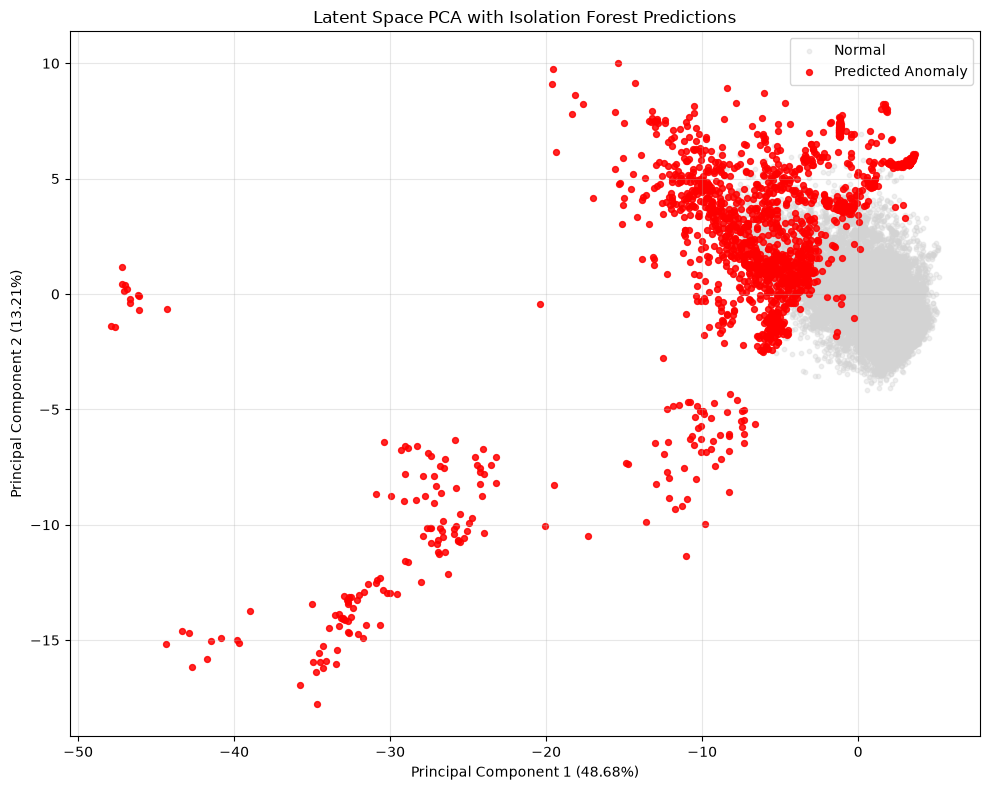

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce latent space to 2D
pca = PCA(n_components=2, random_state=42)
latent_pca = pca.fit_transform(latent_test)

# Boolean masks
normal_mask = predictions == 1
anomaly_mask = predictions == -1

plt.figure(figsize=(10,8))

# Normal flows
plt.scatter(
    latent_pca[normal_mask,0],
    latent_pca[normal_mask,1],
    s=10,
    c='lightgrey',
    alpha=0.35,
    label='Normal'
)

# Anomalies
plt.scatter(
    latent_pca[anomaly_mask,0],
    latent_pca[anomaly_mask,1],
    s=18,
    c='red',
    alpha=0.85,
    label='Predicted Anomaly'
)

plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Latent Space PCA with Isolation Forest Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(latent_test, predictions)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.5268


In [31]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(latent_test, predictions)

print(f"Davies-Bouldin Index: {db_index:.4f}")

Davies-Bouldin Index: 1.7806


In [32]:
results_df = pd.DataFrame(
    latent_test,
    columns=[f"latent_{i+1}" for i in range(latent_test.shape[1])]
)

results_df["flow_index"] = X_test.index
results_df["anomaly_score"] = anomaly_scores
results_df["prediction"] = predictions

# Put flow_index first
results_df = results_df[
    ["flow_index"] +
    [c for c in results_df.columns if c != "flow_index"]
]

results_df.head()

,flow_index,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,anomaly_score,prediction
0,35062,-1.000285,-1.905794,-0.676738,-2.679859,1.789668,3.504605,-0.375457,-1.564394,-2.362860,0.634730,0.391583,1
1,17147,-5.710405,-7.178404,2.523206,-7.201777,5.706228,17.570946,-6.760588,-2.266325,-0.519056,1.422817,0.613028,-1
2,31642,-1.227657,-2.766949,0.999254,-2.488499,1.789285,4.452417,-0.641181,-0.514295,-1.644536,1.698496,0.356193,1
3,75756,-1.343405,-2.062212,1.323815,-3.379874,1.795712,3.191377,-1.321518,0.546480,-2.273471,-0.064397,0.366379,1
4,51239,0.161589,-2.950143,0.536240,-3.445060,1.335759,5.782499,-2.341433,-1.053071,-1.661695,0.192339,0.375460,1


In [35]:

results_df.to_parquet(
   "with_CID_results.parquet",
   index=False
)


In [36]:
X_test.to_parquet("with_CID_test_features.parquet")